In [21]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "rescomp", "rescomp")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Thinned_Rescomp", "utils")))

from helper import get_orbit
from reservoir_workflows import search_best_reservoir, ArtifactLevel
from file_io import save_exemplar_bundle, load_exemplar_bundle
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import scipy as sp
from scipy import optimize
from pathlib import Path

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}",
    "font.family": "serif",
    'font.sans-serif': ['Computer Modern Roman'],
    'font.serif': ['Computer Modern Roman'],
    'font.size': 16
})

### Compute and Save High VPT Matrices

In [22]:
def get_bundle_dir(
    n,
    network_type,
    rho,
    mean_degree,
    alpha,
    gamma,
    sigma,
    tol,
    duration,
    switch
):
    return Path(
        f"data/bundle_n_{n}_n_type_{network_type}_rho_{rho}_mean_degree_{mean_degree}_"
        f"alpha_{alpha}_gamma_{gamma}_sigma_{sigma}_tol_{tol}_duration_{duration}_switch_{switch}/"
    )

In [23]:
def load_bundle_data(n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch):
    bundle_dir = get_bundle_dir(n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch)
    bundle = load_exemplar_bundle(bundle_dir)
    artifacts = bundle["artifacts"]

    A = artifacts["A"]
    r0 = artifacts["r0"]
    t_train = artifacts["t_train"]
    U_train = artifacts["U_train"]
    t_test = artifacts["t_test"]
    U_test = artifacts["U_test"]
    U_hat_pred = artifacts["U_pred"]
    states_train = artifacts["states_train"]
    states_pred = artifacts["states_pred"]
    W_out = artifacts["W_out"]

    # Reconstruct training prediction to keep plotting cells unchanged.
    U_hat_train = (W_out @ states_train.T).T
    vpt = np.array([float(np.asarray(artifacts["vpt"]))])

    return A, r0, t_train, U_train, t_test, U_test, U_hat_train, U_hat_pred, states_train, states_pred, W_out, vpt

In [24]:
def build_and_save_best_reservoir(
    n,
    network_type,
    rho,
    mean_degree,
    alpha,
    gamma,
    sigma,
    tol,
    duration,
    switch,
    draw_count=100,
    vpt_upper_bound=3.5
):
    t_train, U_train, t_test, U_test = get_orbit(duration=duration, system='lorenz', switch=switch)

    # For this notebook flow, erdos_c equals the pre-thinning mean degree.
    erdos_c = mean_degree
    p_thin = 0.0
    param_set = (n, erdos_c, gamma, sigma, alpha)

    bundle_dir = get_bundle_dir(
        n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch
    )

    best_vpt_start = 0.0
    existing_vpt_path = bundle_dir / Path("vpt.npy")
    if existing_vpt_path.is_file():
        best_vpt_start = float(np.load(existing_vpt_path))

    best_result, best_vpt = search_best_reservoir(
        tol=tol,
        t_train=t_train,
        t_test=t_test,
        U_train=U_train,
        U_test=U_test,
        network_type=network_type,
        rho=rho,
        p_thin=p_thin,
        param_set=param_set,
        draw_count=draw_count,
        best_vpt_start=best_vpt_start,
        vpt_upper_bound=vpt_upper_bound,
        artifact_level=ArtifactLevel.FULL_STATES,
    )

    if best_result is None:
        print(f"No improved reservoir found. Current best vpt={best_vpt_start:.4f}")
        return

    save_exemplar_bundle(
        bundle_dir=bundle_dir,
        artifacts=best_result.artifacts,
        mean_attrs=best_result.mean_attrs,
        datasets=best_result.datasets,
        include_datasets=False,
    )

    print(f"Saved bundle to {bundle_dir}")
    print(f"Best vpt: {best_vpt:.4f}")

In [25]:
# Good Parameters from our work
n = 50
network_type = "directed_erdos"
rho = 2
mean_degree = 5
p = mean_degree / n
alpha = 2e-08
gamma = 10
sigma = 0.014
tol = 5.0
duration = 8
switch = 6

build_and_save_best_reservoir(
    n,
    network_type,
    rho,
    mean_degree,
    alpha,
    gamma,
    sigma,
    tol,
    duration,
    switch,
    draw_count=100,
    vpt_upper_bound=3.5,
    )

param_set: (50, 5, 10, 0.014, 2e-08)
First Replica Run
Second Replica Run
Train
Forecast and predict
GIANT SIZE: 50
Divs: (np.float64(0.16308125358682551), np.float64(0.0038598556540589348), np.float64(0.041695235249934993), np.float64(0.01850812994266038))
Mean_attrs: {'mean_giant_diam': np.float64(3.0), 'mean_average_diam': np.float64(3.0), 'mean_giant_size': np.float64(50.0), 'mean_div_pos': np.float64(0.16308125358682551), 'mean_div_der': np.float64(0.0038598556540589348), 'mean_div_spect': np.float64(0.041695235249934993), 'mean_div_rank': np.float64(0.01850812994266038), 'mean_pred': np.float64(3.5727108114387196), 'mean_err': np.float64(13.254539550851248), 'mean_vpt': np.float64(0.8900000000000001), 'mean_consistency_correlation': np.float64(nan)}
param_set: (50, 5, 10, 0.014, 2e-08)
First Replica Run
Second Replica Run
Train
Forecast and predict
GIANT SIZE: 50
Divs: (np.float64(0.1747180581833184), np.float64(0.00425099353296506), np.float64(0.042751917741080205), np.float64(0

In [26]:
# Paper Parameters from the Global Forecasts in Reservoir Computers Paper
# n = 50
# network_type = "undirected_erdos"
# rho = 16.81
# p = 0.1
# mean_degree = n * p
# alpha = 2.7e-08
# gamma = 8.78
# sigma = 0.187
# tol = 5.

In [27]:
A, initial_conditions, t_train, U_train, t_test, U_test, U_hat_train, U_hat_pred, states_train, states_pred, W_out, vpt = load_bundle_data(
    n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch
)

vpt = vpt[0]
reservoir_states = np.vstack((states_train, states_pred))
T = states_train.shape[0]
t = np.arange(reservoir_states.shape[0])
u_true = np.vstack((U_train[:-1], U_test))
u_hat = np.vstack((U_hat_train, U_hat_pred))

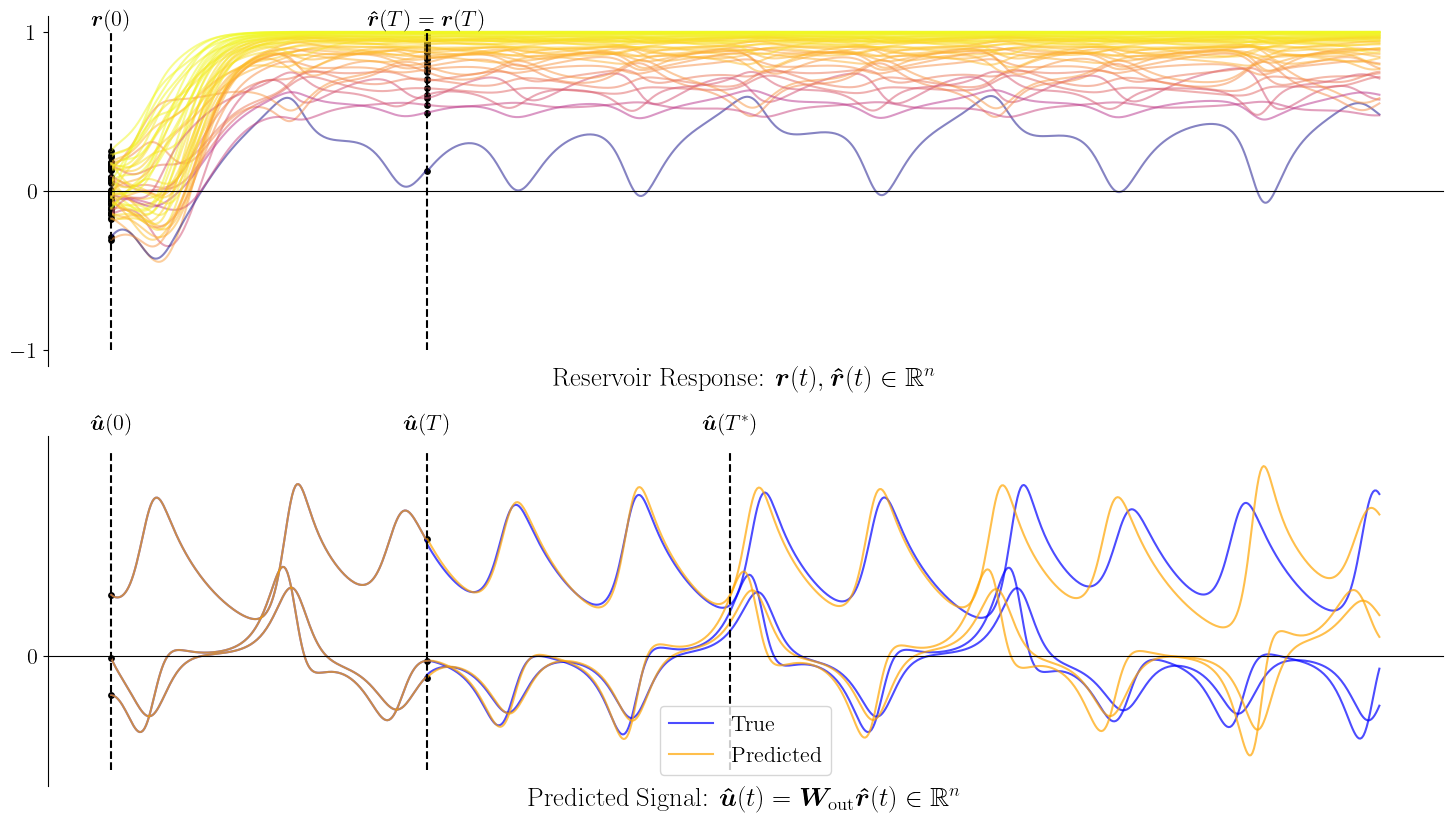

In [28]:
norm = Normalize(vmin=min(initial_conditions), vmax=max(initial_conditions))
cmap = plt.get_cmap('plasma')

fig, axes = plt.subplots(2, 1, figsize=(18,10))

ax1 = axes[0]
for r, r0 in zip(reservoir_states.T, initial_conditions):
    ax1.plot(t, r, color=cmap(norm(r0)), alpha=0.5)


ax1.vlines(x=0, ymin=-1, ymax=1, color="black", linestyles="--")
ax1.scatter(np.zeros(n), reservoir_states[0], c="black", s=15)
ax1.annotate(
    r"$\bm{r}(0)$",
    xy=(0, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax1.vlines(x=T, ymin=-1, ymax=1, color="black", linestyles="--")
ax1.scatter(np.ones(n)*T, reservoir_states[T], c="black", s=15)
ax1.annotate(
    r"$\bm{\hat r}(T) = \bm{r}(T)$",
    xy=(T, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax1.set_yticks([-1,0,1])
ax1.set_xticks([])

ax1.spines['bottom'].set_position(('data', 0))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title(r"Reservoir Response: $\bm{r}(t), \bm{\hat r}(t) \in \mathbb{R}^n$", y=-0.08)

ax2 = axes[1]

for i, u in enumerate(u_true.T):
    if i == 0:
        ax2.plot(t, u, color="blue", label="True", alpha=0.7)
    else:
        ax2.plot(t, u, color="blue", alpha=0.7)

for i, u in enumerate(u_hat.T):
    if i == 0:
        ax2.plot(t, u, color="orange", label="Predicted", alpha=0.7)
    else:
        ax2.plot(t, u, color="orange", alpha=0.7)

signal_bottom = ax2.get_ylim()[0]
signal_top = ax2.get_ylim()[1]

ax2.vlines(x=0, ymin=signal_bottom, ymax=signal_top, color="black", linestyles="--")
ax2.scatter(np.zeros(3), u_hat[0], c="black", s=15)
ax2.annotate(
    r"$\bm{\hat u}(0)$",
    xy=(0, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax2.vlines(x=T, ymin=signal_bottom, ymax=signal_top, color="black", linestyles="--")
ax2.scatter(np.ones(3)*T, u_hat[T], c="black", s=15)
ax2.annotate(
    r"$\bm{\hat u}(T)$",
    xy=(T, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

vpt_x = vpt*100 + T
ax2.vlines(x=(vpt_x), ymin=signal_bottom, ymax=signal_top, color="black", linestyles="--")
ax2.annotate(
    r"$\bm{\hat u}(T^*)$",
    xy=(vpt_x, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax2.set_yticks([0])
ax2.set_xticks([])

ax2.spines['bottom'].set_position(('data', 0))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title(r"Predicted Signal: $\bm{\hat u}(t) = \bm{W}_{\text{out}} \bm{\hat r} (t) \in \mathbb{R}^n$", y=-0.08)


plt.legend()
plt.show()

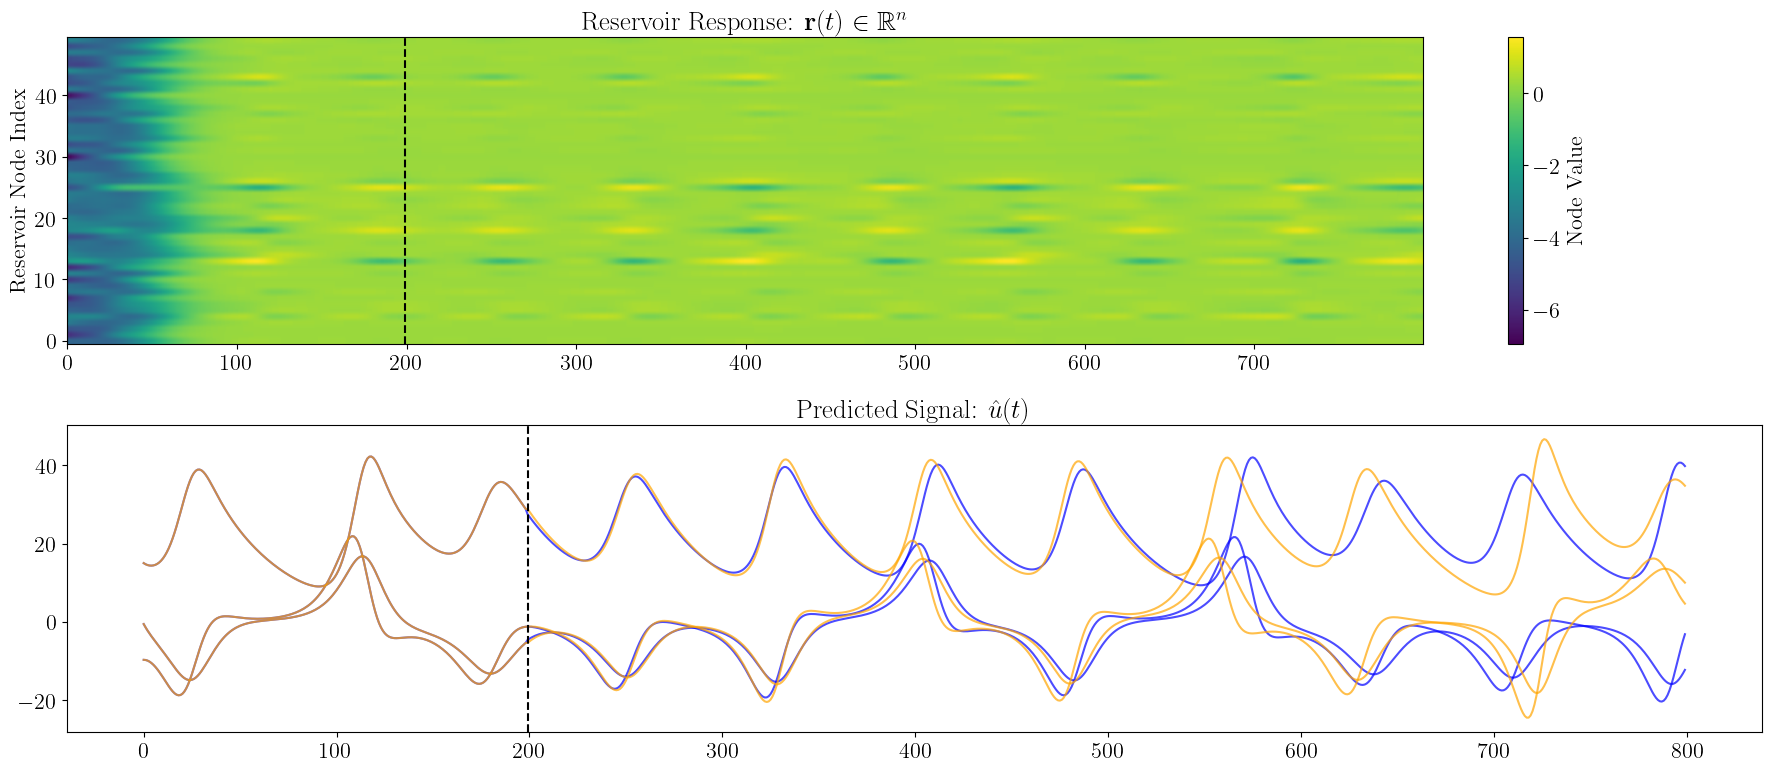

In [29]:
fig, axes = plt.subplots(2,1, figsize=(18,8))

# --- Reservoir state heatmap ---
ax1 = axes[0]

R = reservoir_states
Rnorm = (R - R.mean(axis=0)) / R.std(axis=0)

im = ax1.imshow(Rnorm.T, aspect="auto", origin="lower")

ax1.axvline(0, color="black", linestyle="--")
ax1.axvline(T, color="black", linestyle="--")

ax1.set_ylabel("Reservoir Node Index")
ax1.set_title(r"Reservoir Response: $\mathbf{r}(t) \in \mathbb{R}^n$")

cbar = plt.colorbar(im, ax=ax1)
cbar.set_label("Node Value")

# --- Signal plot ---
ax2 = axes[1]

for i,u in enumerate(u_true.T):
    ax2.plot(t, u, color="blue", alpha=0.7)

for i,u in enumerate(u_hat.T):
    ax2.plot(t, u, color="orange", alpha=0.7)

ax2.axvline(T, color="black", linestyle="--")

ax2.set_title(r"Predicted Signal: $\hat{u}(t)$")

plt.tight_layout()
plt.show()

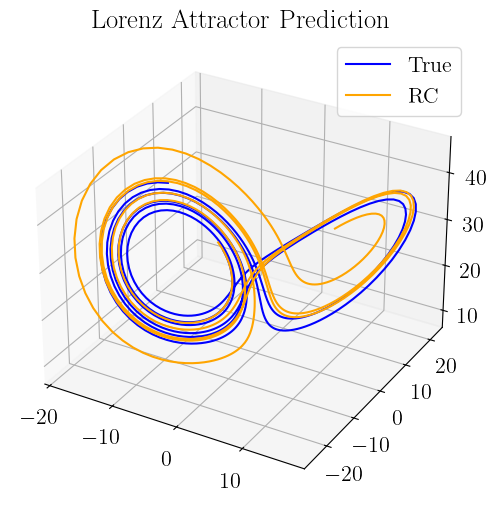

In [30]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection="3d")

ax.plot(*U_test.T, color="blue", label="True")
ax.plot(*U_hat_pred.T, color="orange", label="RC")

ax.set_title("Lorenz Attractor Prediction")
plt.legend()